In [76]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
from joblib import load
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
import scipy.stats as stats

In [77]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, InputLayer
from tensorflow.keras.utils import to_categorical

print(tf.config.list_physical_devices(device_type=None))
physical_devices = tf.config.list_physical_devices('GPU')
print(physical_devices)
tf.config.experimental.set_memory_growth(physical_devices[0], True)

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [78]:
def Generate_Regression_ANOVA(model,X,y):
    params = np.append(model.intercept_,model.coef_)
    predictions = model.predict(X)
    newX = pd.DataFrame({"Constant":np.ones(len(X))}).join(pd.DataFrame(X))
    MSE = (sum((y-predictions)**2))/(len(newX)-len(newX.columns))
    var_b = MSE*(np.linalg.pinv(np.dot(newX.T,newX)).diagonal())
    sd_b = np.sqrt(var_b)
    ts_b = params/ sd_b
    p_values = [2 * (1 - stats.t.cdf(np.abs(i), (len(newX) - len(newX.columns)))) for i in ts_b]
    sd_b = np.round(sd_b,3)
    ts_b = np.round(ts_b,3)
    p_values = np.round(p_values,10)
    params = np.round(params,4)
    myDF3 = pd.DataFrame()
    myDF3["Coefficients"],myDF3["Standard Errors"],myDF3["t values"],myDF3["Probabilities"] = [params,sd_b,ts_b,p_values]
    print(myDF3)

In [138]:
def regression_results(model,data,labels):
    y_true = labels
    y_pred = model.predict(data)
    explained_variance=metrics.explained_variance_score(y_true, y_pred)
    mean_absolute_error=metrics.mean_absolute_error(y_true, y_pred) 
    mse=metrics.mean_squared_error(y_true, y_pred) 
    mean_squared_log_error=metrics.mean_squared_log_error(y_true, y_pred)
    median_absolute_error=metrics.median_absolute_error(y_true, y_pred)
    r2=metrics.r2_score(y_true, y_pred)
    
    try:
        print(f'model coefficents: {model.coef_}')
        N = data.shape[0]
        K = model.coef_.shape[0]
        r2adj = 1 - ((N - 1)/(N - K - 1))*(1 - r2) 
        fstat = (r2/(1-r2))*((N-K-1)/K)
        fprob = 1 - stats.f.cdf(fstat,K-1,N-K)
        print('N: ',N)
        print('K: ',K)
        print('Adj r2:',round(r2adj,4))
        print('F Stat: ',round(fstat,4))
        print('F Prob: ',fprob)
    except:
        pass
    print('explained_variance: ', round(explained_variance,4))    
    print('mean_squared_log_error: ', round(mean_squared_log_error,4))
    print('r2: ', round(r2,4))
    print('MAE: ', round(mean_absolute_error,4))
    print('MSE: ', round(mse,4))
    print('RMSE: ', round(np.sqrt(mse),4))

In [139]:
def regression_results_from_preds(y_true,y_pred):
    explained_variance=metrics.explained_variance_score(y_true, y_pred)
    mean_absolute_error=metrics.mean_absolute_error(y_true, y_pred) 
    mse=metrics.mean_squared_error(y_true, y_pred) 
    mean_squared_log_error=metrics.mean_squared_log_error(y_true, y_pred)
    median_absolute_error=metrics.median_absolute_error(y_true, y_pred)
    r2=metrics.r2_score(y_true, y_pred)
    
    print('explained_variance: ', round(explained_variance,4))    
    print('mean_squared_log_error: ', round(mean_squared_log_error,4))
    print('r2: ', round(r2,4))
    print('MAE: ', round(mean_absolute_error,4))
    print('MSE: ', round(mse,4))
    print('RMSE: ', round(np.sqrt(mse),4))
    

In [140]:
ml_data = pd.read_csv('../Models/ML_Input_Data.csv')

In [141]:
results_df = pd.read_csv('../Models/Medal_Prediction_CV_Results.csv')

In [142]:
ml_data = ml_data[ml_data['Olympics Name'] != 'Milan Cortina 2026']
X = np.array(ml_data[['Pre-Peak Age Athletes','Peak Age Athletes','Post-Peak Age Athletes']])
y = np.array(ml_data['Medal Score'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

In [143]:
lin_reg = load('../Models/LINREG_optimal_medal_prediction_model.joblib')
lasso = load('../Models/LASSO_optimal_medal_prediction_model.joblib')
ridge = load('../Models/RIDGE_optimal_medal_prediction_model.joblib')
rt = load('../Models/RT_optimal_medal_prediction_model.joblib')

C:\Users\Eaj59\miniconda3\envs\pytorch\lib\site-packages\sklearn\base.py:310: UserWarning: Trying to unpickle estimator LinearRegression from version 1.0.2 when using version 0.24.1. This might lead to breaking code or invalid results. Use at your own risk.
  warnings.warn(
C:\Users\Eaj59\miniconda3\envs\pytorch\lib\site-packages\sklearn\base.py:310: UserWarning: Trying to unpickle estimator Lasso from version 1.0.2 when using version 0.24.1. This might lead to breaking code or invalid results. Use at your own risk.
  warnings.warn(
C:\Users\Eaj59\miniconda3\envs\pytorch\lib\site-packages\sklearn\base.py:310: UserWarning: Trying to unpickle estimator Ridge from version 1.0.2 when using version 0.24.1. This might lead to breaking code or invalid results. Use at your own risk.
  warnings.warn(
C:\Users\Eaj59\miniconda3\envs\pytorch\lib\site-packages\sklearn\base.py:310: UserWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.0.2 when using version 0.24.1. This migh

In [175]:
ridge.__dict__

{'alpha': 0.1,
 'fit_intercept': True,
 'normalize': True,
 'copy_X': True,
 'max_iter': None,
 'tol': 0.001,
 'solver': 'auto',
 'positive': False,
 'random_state': None,
 'n_features_in_': 3,
 '_normalize': True,
 'coef_': array([0.03176011, 0.201342  , 0.12768363]),
 'n_iter_': None,
 'intercept_': 0.7387651371525519}

In [144]:
print('Linear Regression Train')
regression_results(model=lin_reg,data=X_train,labels=y_train)
Generate_Regression_ANOVA(lin_reg,X_train,y_train)
print('#################')
print('Linear Regression Test')
regression_results(model=lin_reg,data=X_test,labels=y_test)

Linear Regression Train
model coefficents: [0.00188718 0.2116351  0.14577405]
N:  375
K:  3
Adj r2: 0.2728
F Stat:  47.7642
F Prob:  1.1102230246251565e-16
explained_variance:  0.2786
mean_squared_log_error:  0.9764
r2:  0.2786
MAE:  3.1526
MSE:  30.2833
RMSE:  5.503
   Coefficients  Standard Errors  t values  Probabilities
0        0.7197            0.361     1.995       0.046813
1        0.0019            0.063     0.030       0.976008
2        0.2116            0.087     2.428       0.015652
3        0.1458            0.039     3.763       0.000195
#################
Linear Regression Test
model coefficents: [0.00188718 0.2116351  0.14577405]
N:  186
K:  3
Adj r2: 0.2529
F Stat:  21.8703
F Prob:  3.0433470188384604e-09
explained_variance:  0.265
mean_squared_log_error:  0.98
r2:  0.265
MAE:  2.98
MSE:  25.8711
RMSE:  5.0864


In [145]:
print('Ridge Regression Train')
regression_results(model=ridge,data=X_train,labels=y_train)
Generate_Regression_ANOVA(ridge,X_train,y_train)
print('#################')
print('Ridge Regression Test')
regression_results(model=ridge,data=X_test,labels=y_test)

Ridge Regression Train
model coefficents: [0.03176011 0.201342   0.12768363]
N:  375
K:  3
Adj r2: 0.2715
F Stat:  47.4695
F Prob:  1.1102230246251565e-16
explained_variance:  0.2774
mean_squared_log_error:  0.9955
r2:  0.2774
MAE:  3.1739
MSE:  30.3354
RMSE:  5.5078
   Coefficients  Standard Errors  t values  Probabilities
0        0.7388            0.361     2.046       0.041492
1        0.0318            0.063     0.506       0.613127
2        0.2013            0.087     2.308       0.021547
3        0.1277            0.039     3.293       0.001086
#################
Ridge Regression Test
model coefficents: [0.03176011 0.201342   0.12768363]
N:  186
K:  3
Adj r2: 0.2483
F Stat:  21.3692
F Prob:  4.564392308559206e-09
explained_variance:  0.2605
mean_squared_log_error:  0.9929
r2:  0.2605
MAE:  3.0095
MSE:  26.0291
RMSE:  5.1019


In [146]:
print('Lasso Regression Train')
regression_results(model=lasso,data=X_train,labels=y_train)
Generate_Regression_ANOVA(lasso,X_train,y_train)
print('#################')
print('Lasso Regression Test')
regression_results(model=lasso,data=X_test,labels=y_test)

Lasso Regression Train
model coefficents: [0.         0.18800687 0.15345045]
N:  375
K:  3
Adj r2: 0.2726
F Stat:  47.7091
F Prob:  1.1102230246251565e-16
explained_variance:  0.2784
mean_squared_log_error:  0.9849
r2:  0.2784
MAE:  3.1623
MSE:  30.293
RMSE:  5.5039
   Coefficients  Standard Errors  t values  Probabilities
0        0.7704            0.361     2.135       0.033438
1        0.0000            0.063     0.000       1.000000
2        0.1880            0.087     2.157       0.031672
3        0.1535            0.039     3.960       0.000090
#################
Lasso Regression Test
model coefficents: [0.         0.18800687 0.15345045]
N:  186
K:  3
Adj r2: 0.2517
F Stat:  21.7384
F Prob:  3.3854483660888945e-09
explained_variance:  0.2638
mean_squared_log_error:  0.9909
r2:  0.2638
MAE:  2.9996
MSE:  25.9125
RMSE:  5.0904


In [122]:
print('Tree Regression Train')
regression_results(model=rt,data=X_train,labels=y_train)
print('#################')
print('Tree Regression Test')
regression_results(model=rt,data=X_test,labels=y_test)

Tree Regression Train
explained_variance:  0.3139
mean_squared_log_error:  0.9808
r2:  0.3139
MAE:  3.0688
MSE:  28.801
RMSE:  5.3667
#################
Tree Regression Test
explained_variance:  0.2269
mean_squared_log_error:  1.0616
r2:  0.2269
MAE:  3.061
MSE:  27.2124
RMSE:  5.2165


In [29]:
tf_models_base_path = '../Models/Neural Networks/Trained_NN_Model_'

In [30]:
model_4 = tf.keras.models.load_model(tf_models_base_path+'4')
model_4.summary()

Model: "sequential_11"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_40 (Dense)             (None, 256)               1024      
_________________________________________________________________
dropout (Dropout)            (None, 256)               0         
_________________________________________________________________
dense_41 (Dense)             (None, 128)               32896     
_________________________________________________________________
dropout_1 (Dropout)          (None, 128)               0         
_________________________________________________________________
dense_42 (Dense)             (None, 64)                8256      
_________________________________________________________________
dense_43 (Dense)             (None, 32)                2080      
_________________________________________________________________
dense_44 (Dense)             (None, 1)               

In [37]:
nn_4_train_preds = model_4.predict(X_train)
nn_4_test_preds = model_4.predict(X_test)

In [38]:
print('NN 4 Train')
regression_results_from_preds(y_train,nn_4_train_preds)
print('#################')
print('NN 4 Test')
regression_results_from_preds(y_test,nn_4_test_preds)

NN 4 Train
explained_variance:  0.2909
mean_squared_log_error:  0.8644
r2:  0.2888
MAE:  2.9273
MSE:  29.8559
RMSE:  5.4641
#################
NN 4 Test
explained_variance:  0.2944
mean_squared_log_error:  0.8564
r2:  0.2915
MAE:  2.7902
MSE:  24.9376
RMSE:  4.9938


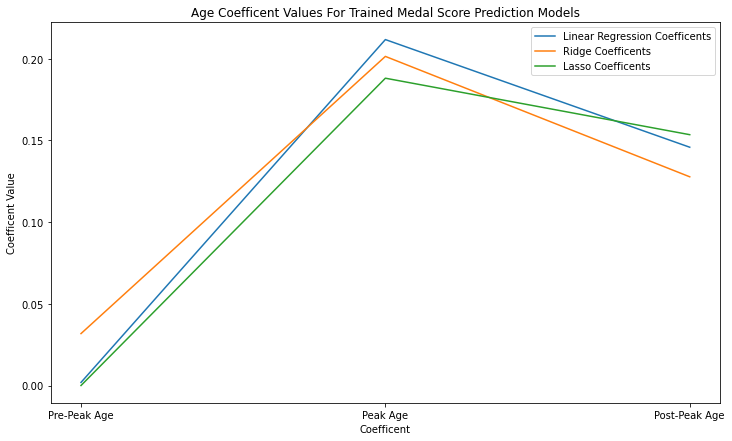

In [153]:
fig = plt.figure(figsize=(12,7))
plt.plot(['Pre-Peak Age','Peak Age', 'Post-Peak Age'],[0.00188718, 0.2116351,0.14577405],label='Linear Regression Coefficents')
plt.plot(['Pre-Peak Age','Peak Age', 'Post-Peak Age'],[0.03176011, 0.201342, 0.12768363],label='Ridge Coefficents')
plt.plot(['Pre-Peak Age','Peak Age', 'Post-Peak Age'],[0.0, 0.18800687, 0.15345045],label='Lasso Coefficents')
plt.legend()
plt.xlabel('Coefficent')
plt.ylabel('Coefficent Value')
plt.title('Age Coefficent Values For Trained Medal Score Prediction Models')
plt.show()
fig.savefig('Age_Coefficents.png')

In [160]:
results_df

,Unnamed: 0,Model Class,param_fit_intercept,param_normalize,param_positive,mean_test_score,mean_train_score,param_max_depth,param_max_leaf_nodes,param_alpha
0,0,LINREG,True,True,True,-31.660977,-30.139657,NaN,NaN,NaN
1,1,LINREG,True,True,False,-31.842205,-30.117856,NaN,NaN,NaN
2,2,LINREG,True,False,True,-31.660977,-30.139657,NaN,NaN,NaN
3,3,LINREG,True,False,False,-31.842205,-30.117856,NaN,NaN,NaN
4,4,LINREG,False,True,True,-31.796765,-30.476288,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
239,95,LASSO,False,False,NaN,-32.283313,-30.680353,NaN,NaN,2.738420
240,96,LASSO,True,True,NaN,-42.259917,-41.948554,NaN,NaN,3.162278
241,97,LASSO,True,False,NaN,-31.956082,-30.414213,NaN,NaN,3.162278
242,98,LASSO,False,True,NaN,-32.331042,-30.739064,NaN,NaN,3.162278


In [183]:
ridge_results = results_df[results_df['Model Class']=='RIDGE'][['Model Class','param_fit_intercept','param_normalize','mean_test_score','mean_train_score','param_alpha']]
ridge_results['param_fit_intercept'] = ridge_results.apply(lambda x: 'Intercept' if x['param_fit_intercept'] else 'No Intercept',axis=1)
ridge_results['param_normalize'] = ridge_results.apply(lambda x: 'Normalized' if x['param_normalize'] else 'No Normalization',axis=1)
ridge_results['int/norm'] = ridge_results.apply(lambda x: x['param_fit_intercept'] +' & '+ x['param_normalize'],axis=1)
ridge_results

,Model Class,param_fit_intercept,param_normalize,mean_test_score,mean_train_score,param_alpha,int/norm
44,RIDGE,Intercept,Normalized,-31.764440,-30.174084,0.100000,Intercept & Normalized
45,RIDGE,Intercept,No Normalization,-31.842197,-30.117856,0.100000,Intercept & No Normalization
46,RIDGE,No Intercept,Normalized,-31.810558,-30.476148,0.100000,No Intercept & Normalized
47,RIDGE,No Intercept,No Normalization,-31.810558,-30.476148,0.100000,No Intercept & No Normalization
48,RIDGE,Intercept,Normalized,-31.767067,-30.188758,0.115478,Intercept & Normalized
...,...,...,...,...,...,...,...
139,RIDGE,No Intercept,No Normalization,-31.810355,-30.476148,2.738420,No Intercept & No Normalization
140,RIDGE,Intercept,Normalized,-35.269103,-34.168704,3.162278,Intercept & Normalized
141,RIDGE,Intercept,No Normalization,-31.841928,-30.117856,3.162278,Intercept & No Normalization
142,RIDGE,No Intercept,Normalized,-31.810322,-30.476148,3.162278,No Intercept & Normalized


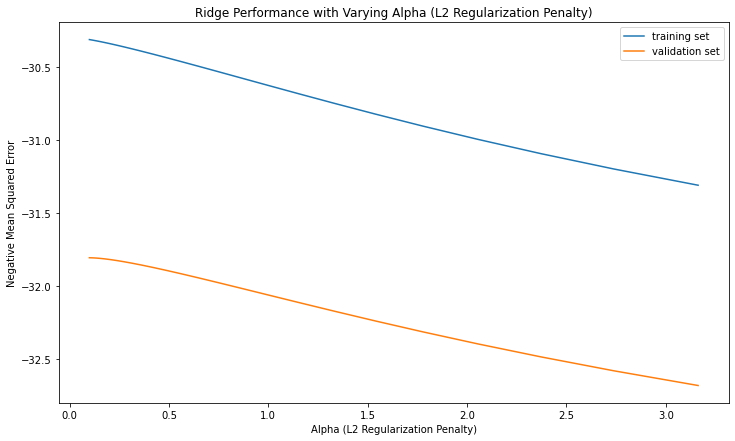

In [184]:
fig = plt.figure(figsize=(12,7))
ridge_alpha_df = ridge_results.groupby(by=['param_alpha']).mean()[['mean_train_score','mean_test_score']].reset_index()
plt.plot(ridge_alpha_df['param_alpha'],ridge_alpha_df['mean_train_score'],label='training set')
plt.plot(ridge_alpha_df['param_alpha'],ridge_alpha_df['mean_test_score'],label='validation set')
plt.ylabel('Negative Mean Squared Error')
plt.title('Ridge Performance with Varying Alpha (L2 Regularization Penalty)')
plt.xlabel('Alpha (L2 Regularization Penalty)')
plt.legend()
plt.show()
fig.savefig('Ridge_Regression_Alpha_Plot.png')

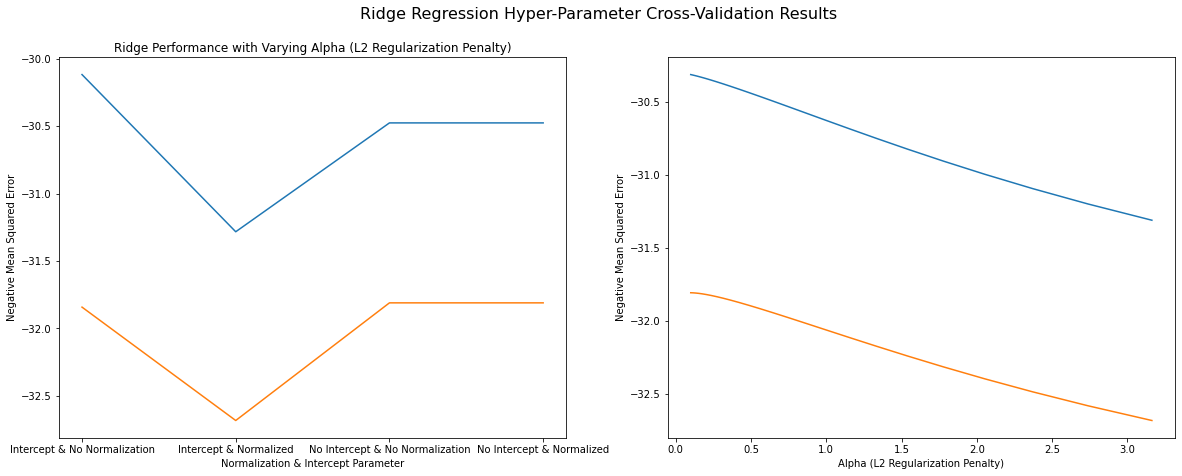

In [174]:
fig = plt.figure(figsize=(20,7))
ax1,ax2 = fig.subplots(1,2)
ridge_norm_int = ridge_results.groupby(by=['int/norm']).mean()[['mean_train_score','mean_test_score']].reset_index()
ax1.plot(ridge_norm_int['int/norm'],ridge_norm_int['mean_train_score'],label='training set')
ax1.plot(ridge_norm_int['int/norm'],ridge_norm_int['mean_test_score'],label='validation set')
ax1.set_title('Ridge Performance with Varying Intercept & Normalization')
ax1.set_ylabel('Negative Mean Squared Error')
ax1.set_xlabel('Normalization & Intercept Parameter')
ridge_alpha_df = ridge_results.groupby(by=['param_alpha']).mean()[['mean_train_score','mean_test_score']].reset_index()
ax2.plot(ridge_alpha_df['param_alpha'],ridge_alpha_df['mean_train_score'],label='training set')
ax2.plot(ridge_alpha_df['param_alpha'],ridge_alpha_df['mean_test_score'],label='validation set')
#ax2.set_title('')
ax2.set_ylabel('Negative Mean Squared Error')
ax1.set_title('Ridge Performance with Varying Alpha (L2 Regularization Penalty)')
ax2.set_xlabel('Alpha (L2 Regularization Penalty)')
fig.suptitle(f'Ridge Regression Hyper-Parameter Cross-Validation Results',fontsize=16)
plt.show()
#fig.savefig('Ridge_CV_Plot.png')

In [157]:
lasso_results = results_df[results_df['Model Class']=='LASSO'][['Model Class','param_fit_intercept','param_normalize','mean_test_score','mean_train_score','param_alpha']]
lasso_results

,Model Class,param_fit_intercept,param_normalize,mean_test_score,mean_train_score,param_alpha
144,LASSO,True,True,-36.588930,-33.372331,0.100000
145,LASSO,True,False,-31.820006,-30.118772,0.100000
146,LASSO,False,True,-31.804816,-30.476566,0.100000
147,LASSO,False,False,-31.804816,-30.476566,0.100000
148,LASSO,True,True,-38.082330,-34.437714,0.115478
...,...,...,...,...,...,...
239,LASSO,False,False,-32.283313,-30.680353,2.738420
240,LASSO,True,True,-42.259917,-41.948554,3.162278
241,LASSO,True,False,-31.956082,-30.414213,3.162278
242,LASSO,False,True,-32.331042,-30.739064,3.162278


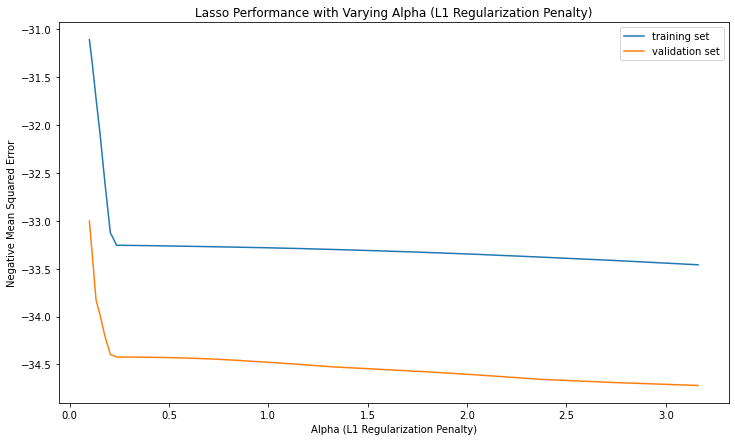

In [182]:
fig = plt.figure(figsize=(12,7))
ridge_alpha_df = lasso_results.groupby(by=['param_alpha']).mean()[['mean_train_score','mean_test_score']].reset_index()
plt.plot(ridge_alpha_df['param_alpha'],ridge_alpha_df['mean_train_score'],label='training set')
plt.plot(ridge_alpha_df['param_alpha'],ridge_alpha_df['mean_test_score'],label='validation set')
plt.ylabel('Negative Mean Squared Error')
plt.title('Lasso Performance with Varying Alpha (L1 Regularization Penalty)')
plt.legend()
plt.xlabel('Alpha (L1 Regularization Penalty)')
plt.show()
fig.savefig('Lasso_Regression_Alpha_Plot.png')

In [159]:
Lin_results = results_df[results_df['Model Class']=='LINREG'][['Model Class','param_fit_intercept','param_normalize','mean_test_score','mean_train_score']]
Lin_results

,Model Class,param_fit_intercept,param_normalize,mean_test_score,mean_train_score
0,LINREG,True,True,-31.660977,-30.139657
1,LINREG,True,True,-31.842205,-30.117856
2,LINREG,True,False,-31.660977,-30.139657
3,LINREG,True,False,-31.842205,-30.117856
4,LINREG,False,True,-31.796765,-30.476288
5,LINREG,False,True,-31.810566,-30.476148
6,LINREG,False,False,-31.796765,-30.476288
7,LINREG,False,False,-31.810566,-30.476148


In [161]:
RT_results = results_df[results_df['Model Class']=='RT'][['Model Class','param_max_depth','param_max_leaf_nodes','mean_test_score','mean_train_score']]
RT_results

,Model Class,param_max_depth,param_max_leaf_nodes,mean_test_score,mean_train_score
8,RT,3.0,3.0,-37.121815,-27.820503
9,RT,3.0,5.0,-42.090351,-24.563509
10,RT,3.0,10.0,-43.758910,-22.702588
11,RT,3.0,15.0,-43.758910,-22.702588
12,RT,3.0,20.0,-43.758910,-22.702588
13,RT,3.0,25.0,-43.758910,-22.702588
14,RT,5.0,3.0,-37.121815,-27.820503
15,RT,5.0,5.0,-42.638456,-24.425965
16,RT,5.0,10.0,-45.151020,-18.245980
17,RT,5.0,15.0,-48.636982,-15.502132


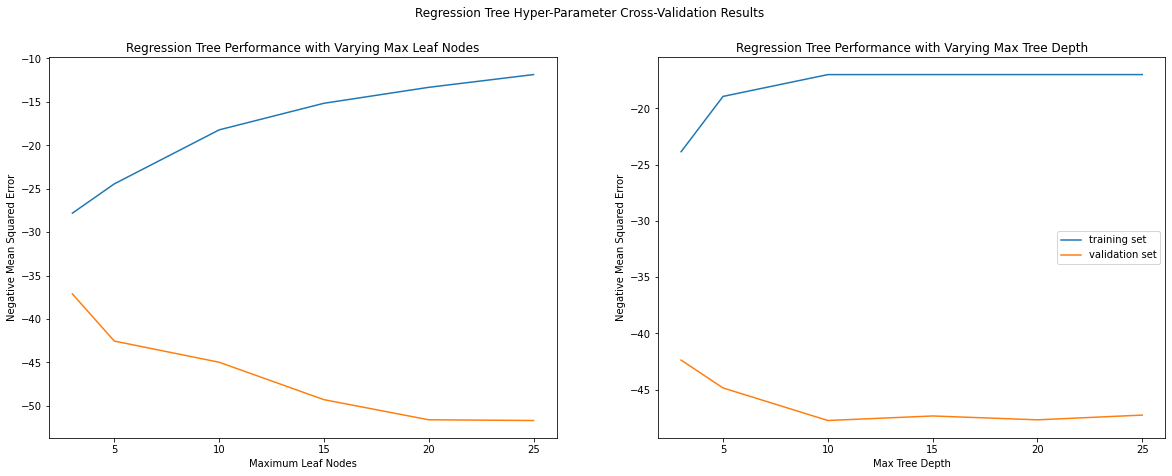

In [191]:
fig = plt.figure(figsize=(20,7))
ax1,ax2 = fig.subplots(1,2)
ridge_norm_int = RT_results.groupby(by=['param_max_leaf_nodes']).mean()[['mean_train_score','mean_test_score']].reset_index()
ax1.plot(ridge_norm_int['param_max_leaf_nodes'],ridge_norm_int['mean_train_score'],label='training set')
ax1.plot(ridge_norm_int['param_max_leaf_nodes'],ridge_norm_int['mean_test_score'],label='validation set')
ax1.set_title('Regression Tree Performance with Varying Max Leaf Nodes')
ax1.set_ylabel('Negative Mean Squared Error')
ax1.set_xlabel('Maximum Leaf Nodes')
ridge_alpha_df = RT_results.groupby(by=['param_max_depth']).mean()[['mean_train_score','mean_test_score']].reset_index()
ax2.plot(ridge_alpha_df['param_max_depth'],ridge_alpha_df['mean_train_score'],label='training set')
ax2.plot(ridge_alpha_df['param_max_depth'],ridge_alpha_df['mean_test_score'],label='validation set')
#ax2.set_title('')
ax2.set_ylabel('Negative Mean Squared Error')
ax2.set_title('Regression Tree Performance with Varying Max Tree Depth')
ax1.set_title('Regression Tree Performance with Varying Max Leaf Nodes')
ax2.set_xlabel('Max Tree Depth')
fig.suptitle(f'Regression Tree Hyper-Parameter Cross-Validation Results')
plt.legend()
plt.show()
fig.savefig('RT_CV_Plot.png')

In [163]:
NN_results = pd.read_csv('../Models/Neural Networks/NN_Model_Histories.csv')
NN_results

,model_num,loss,mean_squared_error,mean_absolute_error,val_loss,val_mean_squared_error,val_mean_absolute_error
0,0,34.104717,34.104717,2.689364,28.302212,28.302212,2.694713
1,0,33.048561,33.048557,2.694750,27.447874,27.447874,2.684759
2,0,32.224346,32.224346,2.696884,26.791401,26.791401,2.676905
3,0,31.658995,31.658995,2.723531,26.319662,26.319662,2.671426
4,0,31.212494,31.212494,2.752628,26.006203,26.006203,2.670086
...,...,...,...,...,...,...,...
70,4,30.828522,30.828522,3.083705,25.256369,25.256369,2.888023
71,4,29.806728,29.806728,3.141767,25.201269,25.201269,2.897748
72,4,31.176849,31.176849,3.188627,24.976297,24.976297,2.850637
73,4,29.714416,29.714416,3.068738,24.936459,24.936459,2.799639


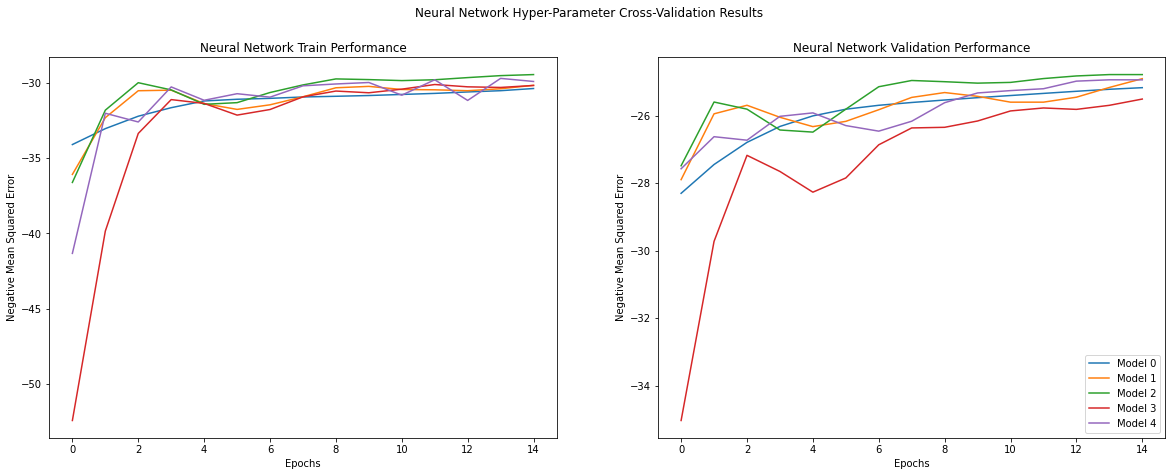

In [193]:
fig = plt.figure(figsize=(20,7))
ax1,ax2 = fig.subplots(1,2)
unique_nn_models = list(NN_results['model_num'].unique())
NN_results['neg_mean_squared_error'] = NN_results.apply(lambda x: -x['mean_squared_error'],axis=1)
NN_results['neg_val_mean_squared_error'] = NN_results.apply(lambda x: -x['val_mean_squared_error'],axis=1)
for i in range(0,len(unique_nn_models)):
    mod_num = unique_nn_models[i]
    nn_result_df_i = NN_results[NN_results['model_num']==mod_num]
    mod_string = 'Model ' + str(mod_num)
    epochs = np.arange(0,nn_result_df_i.shape[0])
    ax1.plot(epochs,nn_result_df_i['neg_mean_squared_error'],label=mod_string)
    ax2.plot(epochs,nn_result_df_i['neg_val_mean_squared_error'],label=mod_string)
    
    
ax1.set_title('Neural Network Train Performance')
ax1.set_ylabel('Negative Mean Squared Error')
ax1.set_xlabel('Epochs')
ax1.set_title('Neural Network Train Performance')
ax2.set_ylabel('Negative Mean Squared Error')
ax2.set_title('Neural Network Validation Performance')
ax2.set_xlabel('Epochs')
fig.suptitle(f'Neural Network Hyper-Parameter Cross-Validation Results')
plt.legend()
plt.show()
fig.savefig('NN_CV_Plot.png')